In [1]:
!pip install xgboost lightgbm

In [2]:
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.metrics import (
    accuracy_score,
    classification_report
)

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from lightgbm import LGBMClassifier

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv(
    "reddit_preprocessed.csv"
)

df.head()

,Unnamed: 0,clean_comment,category,word_count
0,0,family mormon never tried explain still stare ...,1,26
1,1,buddhism much lot compatible christianity espe...,1,140
2,2,seriously say thing first get complex explain ...,-1,46
3,3,learned want teach different focus goal not wr...,0,15
4,4,benefit may want read living buddha living chr...,1,68


In [4]:
X = df["clean_comment"]

y = df["category"]

In [5]:
df['category'] = df['category'].map({
    -1 : 2,
    0: 0,
    1: 1
})

y=df["category"]

In [6]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [8]:
vectorizer = TfidfVectorizer(
    ngram_range=(1,1),
    max_features=10000
)

X_train_vec = vectorizer.fit_transform(
    X_train
)

X_test_vec = vectorizer.transform(
    X_test
)

# **Logistic Regression**

In [13]:
lr = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

lr.fit(
    X_train_vec,
    y_train
)

y_pred = lr.predict(
    X_test_vec
)

print(
    accuracy_score(y_test,y_pred)
)

print(
    classification_report(
        y_test,
        y_pred
    )
)

0.8341919739696312
              precision    recall  f1-score   support

           0       0.81      0.94      0.87      2555
           1       0.91      0.79      0.84      3166
           2       0.76      0.76      0.76      1655

    accuracy                           0.83      7376
   macro avg       0.83      0.83      0.82      7376
weighted avg       0.84      0.83      0.83      7376



In [11]:
lr = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

lr.fit(
    X_train_vec,
    y_train
)

y_pred = lr.predict(
    X_test_vec
)

print(
    accuracy_score(y_test,y_pred)
)

print(
    classification_report(
        y_test,
        y_pred
    )
)

0.8341919739696312
              precision    recall  f1-score   support

           0       0.81      0.94      0.87      2555
           1       0.91      0.79      0.84      3166
           2       0.76      0.76      0.76      1655

    accuracy                           0.83      7376
   macro avg       0.83      0.83      0.82      7376
weighted avg       0.84      0.83      0.83      7376



Random Foredst

In [14]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    random_state=42
)

rf.fit(
    X_train_vec,
    y_train
)

rf_pred = rf.predict(
    X_test_vec
)

rf_acc = accuracy_score(
    y_test,
    rf_pred
)
print(
    accuracy_score(y_test,rf_pred)
)

print(
    classification_report(
        y_test,
        rf_pred
    )
)

0.636117136659436
              precision    recall  f1-score   support

           0       0.65      0.80      0.72      2555
           1       0.62      0.83      0.71      3166
           2       1.00      0.01      0.01      1655

    accuracy                           0.64      7376
   macro avg       0.76      0.55      0.48      7376
weighted avg       0.72      0.64      0.56      7376



# **XGBOOST**

In [15]:
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)

xgb.fit(
    X_train_vec,
    y_train
)

xgb_pred = xgb.predict(
    X_test_vec
)

xgb_acc = accuracy_score(
    y_test,
    xgb_pred
)

print(
    accuracy_score(y_test,xgb_pred)
)

print(
    classification_report(
        y_test,
        xgb_pred
    )
)

0.7795553145336226
              precision    recall  f1-score   support

           0       0.72      0.95      0.82      2555
           1       0.83      0.78      0.81      3166
           2       0.84      0.52      0.64      1655

    accuracy                           0.78      7376
   macro avg       0.79      0.75      0.75      7376
weighted avg       0.79      0.78      0.77      7376



In [16]:
lgbm = LGBMClassifier(
    objective='multiclass',
    num_class=3,
    random_state=42
)

lgbm.fit(
    X_train_vec,
    y_train
)

lgbm_pred = lgbm.predict(
    X_test_vec
)

lgbm_acc = accuracy_score(
    y_test,
    lgbm_pred
)

print(
    accuracy_score(y_test,lgbm_pred)
)

print(
    classification_report(
        y_test,
        lgbm_pred
    )
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 1.169720 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 120938
[LightGBM] [Info] Number of data points in the train set: 29502, number of used features: 3661
[LightGBM] [Info] Start training from score -1.060209
[LightGBM] [Info] Start training from score -0.845774
[LightGBM] [Info] Start training from score -1.494363
0.8474783080260304
              precision    recall  f1-score   support

           0       0.81      0.97      0.89      2555
           1       0.88      0.84      0.86      3166
           2       0.84      0.67      0.75      1655

    accuracy                           0.85      7376
   macro avg       0.85      0.83      0.83      7376
weighted avg       0.85      0.85      0.84      7376



In [18]:
lr_acc = accuracy_score(y_test, y_pred)

results = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "LightGBM"
    ],
    "Accuracy":[
        lr_acc,
        rf_acc,
        xgb_acc,
        lgbm_acc
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.834192
1,Random Forest,0.636117
2,XGBoost,0.779555
3,LightGBM,0.847478


In [19]:
results.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy
3,LightGBM,0.847478
0,Logistic Regression,0.834192
2,XGBoost,0.779555
1,Random Forest,0.636117


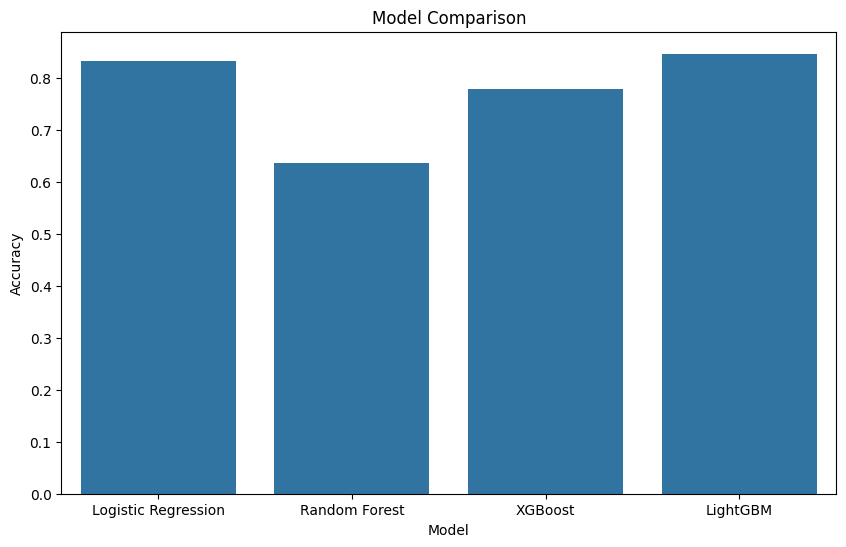

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.barplot(
    data = results,
    x="Model",
    y="Accuracy"


)

plt.title("Model Comparison")
plt.show()

In [21]:
best_model = results.loc[
    results["Accuracy"].idxmax()
]

best_model

,3
Model,LightGBM
Accuracy,0.847478


In [22]:
results.to_csv(
    "model_comparison.csv",
    index=False
)